In [1]:
# CELL 1 — Setup
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style('whitegrid')

In [2]:
# CELL 2 — Generate synthetic territories, reps, and HCPs
N_TERRITORIES = 20
N_REPS = 20
N_HCPS = 600

REGIONS = ['Northeast', 'Southeast', 'Midwest', 'Southwest', 'West']
SPECIALTIES = ['Primary Care', 'Cardiology', 'Endocrinology', 'Oncology']

# Territories
territories = pd.DataFrame({
    'territory_id': [f'T{i:03d}' for i in range(N_TERRITORIES)],
    'region': np.random.choice(REGIONS, N_TERRITORIES),
})

# Reps — one per territory, with tenure and current call capacity
reps = pd.DataFrame({
    'rep_id': [f'REP{i:03d}' for i in range(N_REPS)],
    'territory_id': territories['territory_id'].values,
    'tenure_years': np.round(np.random.exponential(3, N_REPS), 1).clip(0.2, 15),
    'weekly_call_capacity': np.random.randint(30, 55, N_REPS),  # max calls/week a rep can realistically make
})

# HCPs (prescribers) — each assigned to a territory, with a potential/priority score
hcp_territory = np.random.choice(territories['territory_id'], N_HCPS)
hcp_region = territories.set_index('territory_id').loc[hcp_territory, 'region'].values

# Potential score: driven by patient volume + specialty weighting (oncology/cardiology = higher value)
specialty = np.random.choice(SPECIALTIES, N_HCPS, p=[0.45, 0.25, 0.15, 0.15])
specialty_weight = pd.Series(specialty).map({
    'Primary Care': 1.0, 'Cardiology': 1.6, 'Endocrinology': 1.4, 'Oncology': 2.0
}).values

base_potential = np.random.gamma(shape=2.0, scale=25, size=N_HCPS)
potential_score = np.round(base_potential * specialty_weight, 1)

# Current call frequency (calls/quarter) — some HCPs under-called relative to potential
current_calls_per_quarter = np.random.poisson(potential_score / 15, N_HCPS).clip(0, None)

# Decile ranking within each territory (mirrors the HCP Targeting project's NTILE logic)
hcps = pd.DataFrame({
    'hcp_id': [f'HCP{i:05d}' for i in range(N_HCPS)],
    'territory_id': hcp_territory,
    'region': hcp_region,
    'specialty': specialty,
    'potential_score': potential_score,
    'current_calls_per_quarter': current_calls_per_quarter,
})

hcps.head()

,hcp_id,territory_id,region,specialty,potential_score,current_calls_per_quarter
0,HCP00000,T017,West,Cardiology,49.3,2
1,HCP00001,T011,Midwest,Endocrinology,28.2,1
2,HCP00002,T001,West,Primary Care,56.7,3
3,HCP00003,T009,West,Primary Care,56.0,2
4,HCP00004,T003,West,Primary Care,74.0,6


In [3]:
# CELL 3 — Territory-level rollups: workload vs capacity
territory_summary = hcps.groupby('territory_id').agg(
    hcp_count=('hcp_id', 'count'),
    total_potential=('potential_score', 'sum'),
    avg_potential=('potential_score', 'mean'),
    total_current_calls=('current_calls_per_quarter', 'sum'),
).reset_index()

territory_summary = territory_summary.merge(reps[['territory_id', 'rep_id', 'tenure_years', 'weekly_call_capacity']], on='territory_id')
territory_summary['quarterly_capacity'] = territory_summary['weekly_call_capacity'] * 13  # 13 weeks/quarter

# Workload ratio: how many HCPs (weighted by potential) per unit of rep capacity
territory_summary['potential_per_capacity'] = (territory_summary['total_potential'] / territory_summary['quarterly_capacity']).round(3)
territory_summary['calls_vs_capacity_pct'] = (territory_summary['total_current_calls'] / territory_summary['quarterly_capacity'] * 100).round(1)

territory_summary.sort_values('potential_per_capacity', ascending=False)

,territory_id,hcp_count,total_potential,avg_potential,total_current_calls,rep_id,tenure_years,weekly_call_capacity,quarterly_capacity,potential_per_capacity,calls_vs_capacity_pct
11,T011,34,2772.5,81.544118,166,REP011,12.3,33,429,6.463,38.7
16,T016,38,2595.6,68.305263,178,REP016,0.2,35,455,5.705,39.1
0,T000,47,3678.8,78.272340,238,REP000,2.8,50,650,5.660,36.6
4,T004,40,2620.3,65.507500,161,REP004,1.5,36,468,5.599,34.4
19,T019,29,2331.1,80.382759,149,REP019,1.5,33,429,5.434,34.7
15,T015,37,2144.7,57.964865,151,REP015,1.8,31,403,5.322,37.5
8,T008,29,1991.0,68.655172,151,REP008,0.3,32,416,4.786,36.3
1,T001,25,1838.0,73.520000,131,REP001,0.2,31,403,4.561,32.5
12,T012,34,2607.2,76.682353,169,REP012,1.9,47,611,4.267,27.7
18,T018,30,2068.7,68.956667,111,REP018,2.5,39,507,4.080,21.9


In [4]:
# CELL 4 — Flag over/under-served territories (sizing recommendation logic)
median_ratio = territory_summary['potential_per_capacity'].median()

def sizing_flag(ratio):
    if ratio > median_ratio * 1.3:
        return 'Understaffed — consider adding capacity'
    elif ratio < median_ratio * 0.7:
        return 'Overstaffed — consider reallocating'
    else:
        return 'Balanced'

territory_summary['sizing_recommendation'] = territory_summary['potential_per_capacity'].apply(sizing_flag)

print(territory_summary['sizing_recommendation'].value_counts())
territory_summary[['territory_id', 'region', 'hcp_count', 'total_potential', 'quarterly_capacity', 'potential_per_capacity', 'sizing_recommendation']]

sizing_recommendation
Balanced                                   10
Understaffed — consider adding capacity     6
Overstaffed — consider reallocating         4
Name: count, dtype: int64


KeyError: "['region'] not in index"

In [5]:
# CELL 3 — Territory-level rollups: workload vs capacity
territory_summary = hcps.groupby('territory_id').agg(
    hcp_count=('hcp_id', 'count'),
    total_potential=('potential_score', 'sum'),
    avg_potential=('potential_score', 'mean'),
    total_current_calls=('current_calls_per_quarter', 'sum'),
).reset_index()

# Merge in region from territories, and rep info from reps
territory_summary = territory_summary.merge(territories[['territory_id', 'region']], on='territory_id')
territory_summary = territory_summary.merge(reps[['territory_id', 'rep_id', 'tenure_years', 'weekly_call_capacity']], on='territory_id')
territory_summary['quarterly_capacity'] = territory_summary['weekly_call_capacity'] * 13  # 13 weeks/quarter

# Workload ratio: how many HCPs (weighted by potential) per unit of rep capacity
territory_summary['potential_per_capacity'] = (territory_summary['total_potential'] / territory_summary['quarterly_capacity']).round(3)
territory_summary['calls_vs_capacity_pct'] = (territory_summary['total_current_calls'] / territory_summary['quarterly_capacity'] * 100).round(1)

territory_summary.sort_values('potential_per_capacity', ascending=False)

,territory_id,hcp_count,total_potential,avg_potential,total_current_calls,region,rep_id,tenure_years,weekly_call_capacity,quarterly_capacity,potential_per_capacity,calls_vs_capacity_pct
11,T011,34,2772.5,81.544118,166,Midwest,REP011,12.3,33,429,6.463,38.7
16,T016,38,2595.6,68.305263,178,Southwest,REP016,0.2,35,455,5.705,39.1
0,T000,47,3678.8,78.272340,238,Southwest,REP000,2.8,50,650,5.660,36.6
4,T004,40,2620.3,65.507500,161,West,REP004,1.5,36,468,5.599,34.4
19,T019,29,2331.1,80.382759,149,Southwest,REP019,1.5,33,429,5.434,34.7
15,T015,37,2144.7,57.964865,151,Southeast,REP015,1.8,31,403,5.322,37.5
8,T008,29,1991.0,68.655172,151,Midwest,REP008,0.3,32,416,4.786,36.3
1,T001,25,1838.0,73.520000,131,West,REP001,0.2,31,403,4.561,32.5
12,T012,34,2607.2,76.682353,169,West,REP012,1.9,47,611,4.267,27.7
18,T018,30,2068.7,68.956667,111,Northeast,REP018,2.5,39,507,4.080,21.9


In [6]:
# CELL 4 — Flag over/under-served territories (sizing recommendation logic)
median_ratio = territory_summary['potential_per_capacity'].median()

def sizing_flag(ratio):
    if ratio > median_ratio * 1.3:
        return 'Understaffed — consider adding capacity'
    elif ratio < median_ratio * 0.7:
        return 'Overstaffed — consider reallocating'
    else:
        return 'Balanced'

territory_summary['sizing_recommendation'] = territory_summary['potential_per_capacity'].apply(sizing_flag)

print(territory_summary['sizing_recommendation'].value_counts())
territory_summary[['territory_id', 'region', 'hcp_count', 'total_potential', 'quarterly_capacity', 'potential_per_capacity', 'sizing_recommendation']]

sizing_recommendation
Balanced                                   10
Understaffed — consider adding capacity     6
Overstaffed — consider reallocating         4
Name: count, dtype: int64


,territory_id,region,hcp_count,total_potential,quarterly_capacity,potential_per_capacity,sizing_recommendation
0,T000,Southwest,47,3678.8,650,5.660,Understaffed — consider adding capacity
1,T001,West,25,1838.0,403,4.561,Balanced
2,T002,Midwest,41,2031.9,637,3.190,Balanced
3,T003,West,26,1826.8,572,3.194,Balanced
4,T004,West,40,2620.3,468,5.599,Understaffed — consider adding capacity
5,T005,Southeast,21,1478.5,533,2.774,Balanced
6,T006,Midwest,30,1685.7,481,3.505,Balanced
7,T007,Midwest,29,1912.3,572,3.343,Balanced
8,T008,Midwest,29,1991.0,416,4.786,Balanced
9,T009,West,24,1369.5,559,2.450,Overstaffed — consider reallocating


In [7]:
# CELL 5 — HCP call-priority ranking within each territory (NTILE-style, matches your HCP Targeting project)
hcps['call_gap'] = (hcps['potential_score'] / 15 - hcps['current_calls_per_quarter']).round(1)  # expected vs actual calls
hcps['priority_decile'] = hcps.groupby('territory_id')['potential_score'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1
)

# Top-priority under-called HCPs — the actionable "call these first" list
priority_list = hcps[(hcps['priority_decile'] >= 9) & (hcps['call_gap'] > 2)].sort_values('call_gap', ascending=False)
print(f"{len(priority_list)} high-priority, under-called HCPs identified")
priority_list.head(15)

33 high-priority, under-called HCPs identified


,hcp_id,territory_id,region,specialty,potential_score,current_calls_per_quarter,call_gap,priority_decile
309,HCP00309,T011,Midwest,Oncology,337.5,12,10.5,10
83,HCP00083,T019,Southwest,Primary Care,145.4,3,6.7,9
311,HCP00311,T000,Southwest,Primary Care,131.7,3,5.8,9
583,HCP00583,T016,Southwest,Cardiology,227.4,10,5.2,10
47,HCP00047,T002,Midwest,Primary Care,82.8,1,4.5,9
188,HCP00188,T002,Midwest,Cardiology,141.5,5,4.4,10
443,HCP00443,T017,West,Oncology,168.9,7,4.3,10
30,HCP00030,T002,Midwest,Primary Care,77.9,1,4.2,9
237,HCP00237,T013,Southeast,Oncology,123.3,4,4.2,10
540,HCP00540,T018,Northeast,Primary Care,137.4,5,4.2,9


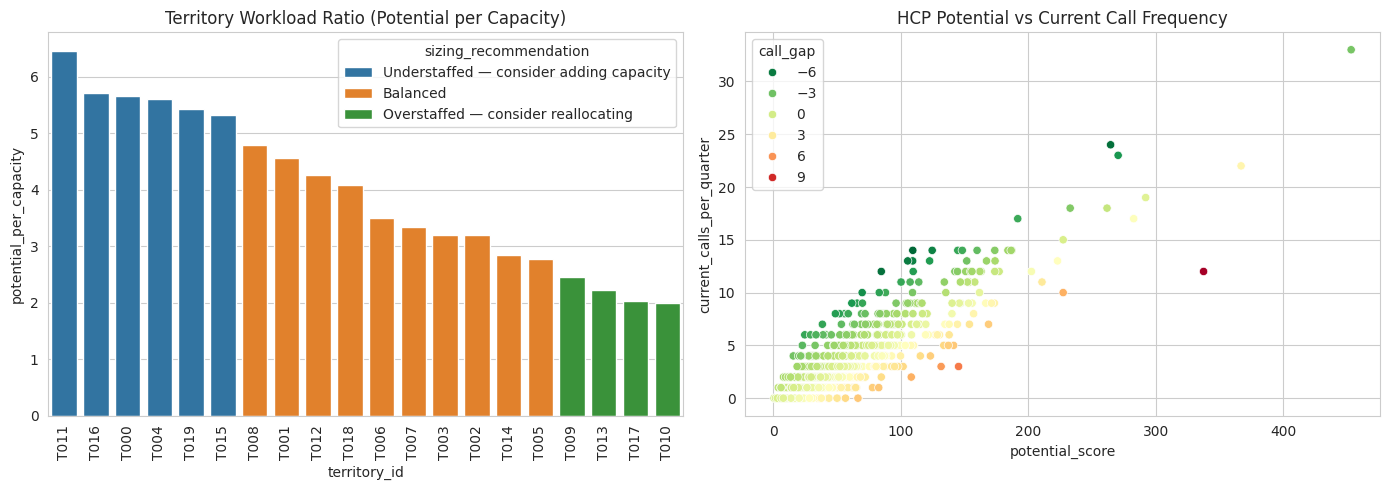

In [8]:
# CELL 6 — Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=territory_summary.sort_values('potential_per_capacity', ascending=False),
            x='territory_id', y='potential_per_capacity', hue='sizing_recommendation',
            dodge=False, ax=axes[0])
axes[0].set_title('Territory Workload Ratio (Potential per Capacity)')
axes[0].tick_params(axis='x', rotation=90)

sns.scatterplot(data=hcps, x='potential_score', y='current_calls_per_quarter',
                 hue='call_gap', palette='RdYlGn_r', ax=axes[1])
axes[1].set_title('HCP Potential vs Current Call Frequency')

plt.tight_layout()
plt.savefig('territory_analysis.png', dpi=150)
plt.show()

In [9]:
# CELL 7 — Build a SQLite database (this is the "SQL" deliverable piece)
conn = sqlite3.connect('territory_optimization.db')

territories.to_sql('territories', conn, if_exists='replace', index=False)
reps.to_sql('reps', conn, if_exists='replace', index=False)
hcps.to_sql('hcps', conn, if_exists='replace', index=False)
territory_summary.to_sql('territory_summary', conn, if_exists='replace', index=False)

# Example analytical SQL query — territories ranked by workload imbalance
query = """
SELECT
    t.territory_id,
    t.region,
    ts.hcp_count,
    ts.total_potential,
    ts.quarterly_capacity,
    ts.potential_per_capacity,
    ts.sizing_recommendation,
    RANK() OVER (ORDER BY ts.potential_per_capacity DESC) as workload_rank
FROM territories t
JOIN territory_summary ts ON t.territory_id = ts.territory_id
ORDER BY workload_rank
"""
result = pd.read_sql(query, conn)
print(result)

   territory_id     region  hcp_count  total_potential  quarterly_capacity  \
0          T011    Midwest         34           2772.5                 429   
1          T016  Southwest         38           2595.6                 455   
2          T000  Southwest         47           3678.8                 650   
3          T004       West         40           2620.3                 468   
4          T019  Southwest         29           2331.1                 429   
5          T015  Southeast         37           2144.7                 403   
6          T008    Midwest         29           1991.0                 416   
7          T001       West         25           1838.0                 403   
8          T012       West         34           2607.2                 611   
9          T018  Northeast         30           2068.7                 507   
10         T006    Midwest         30           1685.7                 481   
11         T007    Midwest         29           1912.3          

In [10]:
# CELL 8 — Export everything
hcps.to_csv('hcps.csv', index=False)
territories.to_csv('territories.csv', index=False)
reps.to_csv('reps.csv', index=False)
territory_summary.to_csv('territory_summary.csv', index=False)
priority_list.to_csv('priority_call_list.csv', index=False)

from google.colab import files
files.download('hcps.csv')
files.download('territories.csv')
files.download('reps.csv')
files.download('territory_summary.csv')
files.download('priority_call_list.csv')
files.download('territory_optimization.db')

print('Exported. Upload all to your GitHub repo under /data/.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exported. Upload all to your GitHub repo under /data/.
